<a href="https://colab.research.google.com/github/daniellezcanorios/mi-app-streamlit/blob/main/Clasificacion_Proyecto_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de grupo de análisis de material (Clasificación)

JUAN FERNANDO PATIÑO

DANIEL LEZCANO RIOS


1. Preparación de Datos
2. Validación cruzada
3. Aprendizaje y evaluación de los Modelos
4. selección del modelo  y Guardar el modelo

* El despliegue se realiza en otro jupyter_notebook

In [ ]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

# 1. Preparación de Datos


In [ ]:
#Cargamos los datos
data = pd.read_excel("resultados_Kmeans_ProyFinal.xlsx", sheet_name="Sheet1")
data.head()

,ID,Unidad Medida,Numero de Transacciones,Cantidad,Reintegros,Precio Unitario,Entrega,Grupo de Analisis
0,0,UN,1,-1.0,0,1750.000,TOTAL,0
1,1,UN,1,-10.0,0,754.000,TOTAL,0
2,2,UN,1,-91.0,0,290.000,PARCIAL,1
3,3,UN,5,-18.0,0,5332.334,TOTAL,0
4,4,UN,9,-50.0,0,11136.050,TOTAL,0


In [ ]:
#Conocemos los datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2345 entries, 0 to 2344
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       2345 non-null   int64  
 1   Unidad Medida            2345 non-null   object 
 2   Numero de Transacciones  2345 non-null   int64  
 3   Cantidad                 2345 non-null   float64
 4   Reintegros               2345 non-null   int64  
 5   Precio Unitario          2345 non-null   float64
 6   Entrega                  2345 non-null   object 
 7   Grupo de Analisis        2345 non-null   int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 146.7+ KB


In [ ]:
# Eliminar variables que no se usarán en el modelo
data = data.drop(columns=['ID'])

In [ ]:
# Se define valores categóricos a los Clusters
mapeo_clusters = {0:'Normal UN', 1:'Crítico Mayor', 2:'Normal ML', 3:'Normal KG', 4:'Crítico Reintegro', 5:'Crítico ML', 6:'Normal LT'}
data['Grupo de Analisis'] = data['Grupo de Analisis'].map(mapeo_clusters)
print(data['Grupo de Analisis'].unique())
data.head()

['Normal UN' 'Crítico Mayor' 'Crítico Reintegro' 'Normal LT' 'Normal KG'
 'Normal ML' 'Crítico ML']


,Unidad Medida,Numero de Transacciones,Cantidad,Reintegros,Precio Unitario,Entrega,Grupo de Analisis
0,UN,1,-1.0,0,1750.000,TOTAL,Normal UN
1,UN,1,-10.0,0,754.000,TOTAL,Normal UN
2,UN,1,-91.0,0,290.000,PARCIAL,Crítico Mayor
3,UN,5,-18.0,0,5332.334,TOTAL,Normal UN
4,UN,9,-50.0,0,11136.050,TOTAL,Normal UN


In [ ]:
#Corrección tipos de datos
data['Unidad Medida']=data['Unidad Medida'].astype('category')
data['Entrega']=data['Entrega'].astype('category')
data['Grupo de Analisis']=data['Grupo de Analisis'].astype('category')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2345 entries, 0 to 2344
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Unidad Medida            2345 non-null   category
 1   Numero de Transacciones  2345 non-null   int64   
 2   Cantidad                 2345 non-null   float64 
 3   Reintegros               2345 non-null   int64   
 4   Precio Unitario          2345 non-null   float64 
 5   Entrega                  2345 non-null   category
 6   Grupo de Analisis        2345 non-null   category
dtypes: category(3), float64(2), int64(2)
memory usage: 81.0 KB


In [ ]:
#Descripción de variables numéricas
data.describe()

,Numero de Transacciones,Cantidad,Reintegros,Precio Unitario
count,2345.000000,2345.000000,2345.000000,2.345000e+03
mean,2.664392,-88.101691,7.572708,1.627424e+06
std,4.912497,921.917954,197.535027,8.628105e+06
min,1.000000,-28612.000000,0.000000,8.940000e+00
25%,1.000000,-15.000000,0.000000,1.183276e+04
50%,1.000000,-4.000000,0.000000,6.783000e+04
75%,3.000000,-1.000000,0.000000,6.051800e+05
max,131.000000,0.000000,8640.000000,3.003104e+08


<Axes: >

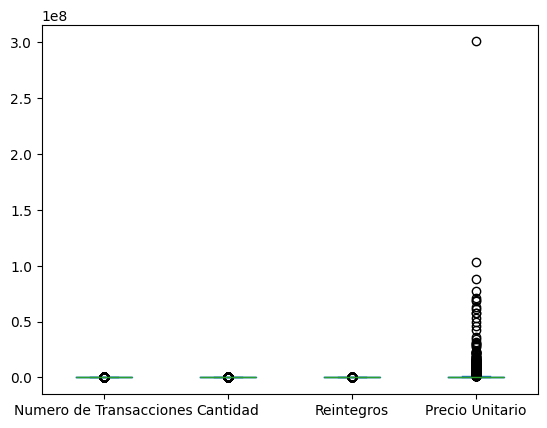

In [ ]:
#Descripción variables numéricas
data.plot(kind='box')

<Axes: xlabel='Unidad Medida'>

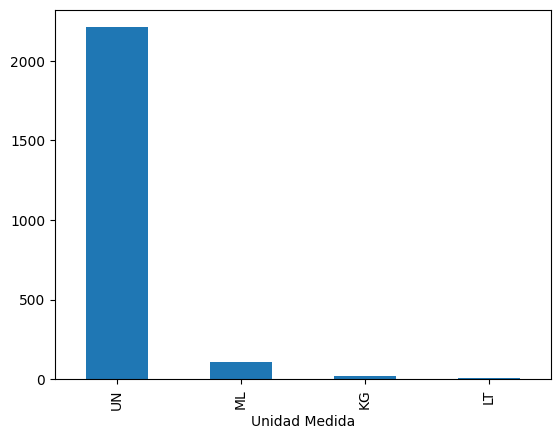

In [ ]:
#Descripción variables categóricas
data['Unidad Medida'].value_counts().plot(kind='bar')

<Axes: xlabel='Entrega'>

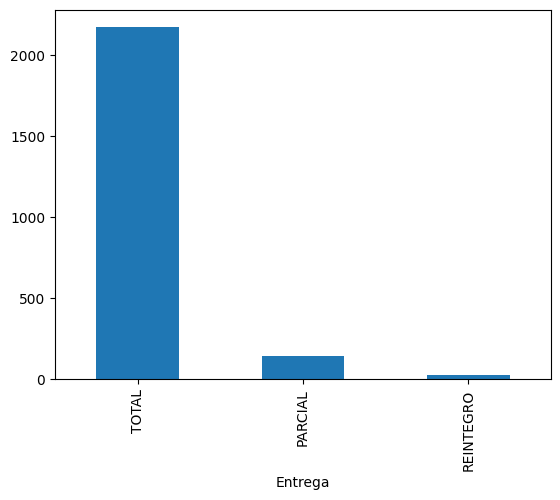

In [ ]:
#Descripción variables categóricas
data['Entrega'].value_counts().plot(kind='bar')

<Axes: xlabel='Grupo de Analisis'>

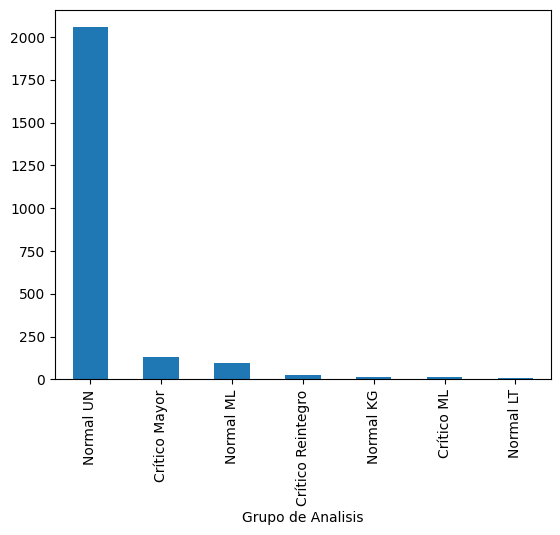

In [ ]:
#Descripción variables categóricas
data['Grupo de Analisis'].value_counts().plot(kind='bar')

In [ ]:
#Configuración de variables
objetivo='Grupo de Analisis'
predictoras_numericas=['Numero de Transacciones','Cantidad','Reintegros','Precio Unitario']
predictoras_categoricas_multicat=['Unidad Medida', 'Entrega']

In [ ]:
data.head()

,Unidad Medida,Numero de Transacciones,Cantidad,Reintegros,Precio Unitario,Entrega,Grupo de Analisis
0,UN,1,-1.0,0,1750.000,TOTAL,Normal UN
1,UN,1,-10.0,0,754.000,TOTAL,Normal UN
2,UN,1,-91.0,0,290.000,PARCIAL,Crítico Mayor
3,UN,5,-18.0,0,5332.334,TOTAL,Normal UN
4,UN,9,-50.0,0,11136.050,TOTAL,Normal UN


<Axes: xlabel='Grupo de Analisis'>

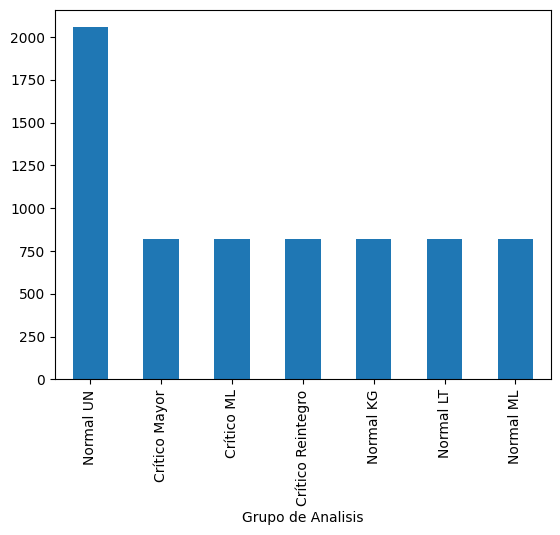

In [ ]:
# Balanceo de datos
from imblearn.over_sampling import SMOTENC
import pandas as pd

# Separamos las variables predictoras (X) y el objetivo (Y)
X = data.drop(objetivo, axis=1)
Y = data[objetivo]

# Calcular la distribución actual de las clases
cuenta_clases = Y.value_counts()

# Determinar el número objetivo de muestras para las clases minoritarias
# El objetivo es que alcancen el 40% del tamaño de la clase mayoritaria
tamaño_clase_mayoritaria = cuenta_clases.max()
objetivo_muestras = int(tamaño_clase_mayoritaria * 0.4)

# Crear un diccionario para la estrategia de muestreo (sampling_strategy)
# Para cada clase: si su conteo actual es menor al objetivo, se remuestrea.
# Si ya es mayor o igual, se mantiene su conteo original.
estrategia_muestreo = {
    clase: max(conteo, objetivo_muestras)
    for clase, conteo in cuenta_clases.items()
}

# Inicializar SMOTENC
# categorical_features=[0, 5] indica qué columnas son categóricas por su índice
smote = SMOTENC(k_neighbors=3, categorical_features=[0, 5], sampling_strategy=estrategia_muestreo)

# Aplicar el balanceo
X_resampled, y_resampled = smote.fit_resample(X, Y)

# Creamos un nuevo DataFrame con los resultados balanceados
data  = pd.DataFrame(columns=X_resampled.columns.values, data=X_resampled)
data[objetivo]=y_resampled
data[objetivo].value_counts().plot(kind='bar')

In [ ]:
#Dummies para las variables predictoras
data = pd.get_dummies(data, columns=predictoras_categoricas_multicat, drop_first=False, dtype=int) #3 o más categorías

data.head()

,Numero de Transacciones,Cantidad,Reintegros,Precio Unitario,Grupo de Analisis,Unidad Medida_KG,Unidad Medida_LT,Unidad Medida_ML,Unidad Medida_UN,Entrega_PARCIAL,Entrega_REINTEGRO,Entrega_TOTAL
0,1,-1.0,0,1750.000,Normal UN,0,0,0,1,0,0,1
1,1,-10.0,0,754.000,Normal UN,0,0,0,1,0,0,1
2,1,-91.0,0,290.000,Crítico Mayor,0,0,0,1,1,0,0
3,5,-18.0,0,5332.334,Normal UN,0,0,0,1,0,0,1
4,9,-50.0,0,11136.050,Normal UN,0,0,0,1,0,0,1


In [ ]:
#LabelEncoder para la variable objetivo
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
data[objetivo] = labelencoder.fit_transform(data[objetivo])
data

,Numero de Transacciones,Cantidad,Reintegros,Precio Unitario,Grupo de Analisis,Unidad Medida_KG,Unidad Medida_LT,Unidad Medida_ML,Unidad Medida_UN,Entrega_PARCIAL,Entrega_REINTEGRO,Entrega_TOTAL
0,1,-1.000000,0,1750.000000,6,0,0,0,1,0,0,1
1,1,-10.000000,0,754.000000,6,0,0,0,1,0,0,1
2,1,-91.000000,0,290.000000,1,0,0,0,1,1,0,0
3,5,-18.000000,0,5332.334000,6,0,0,0,1,0,0,1
4,9,-50.000000,0,11136.050000,6,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
6983,2,-20.833896,0,16794.271435,5,0,0,1,0,0,0,1
6984,2,-89.230378,0,587.779702,5,0,0,1,0,0,0,1
6985,1,-92.121923,0,68044.562721,5,0,0,1,0,0,0,1
6986,4,-415.352557,0,2731.648271,5,0,0,1,0,0,0,1


# 2. Validación cruzada

In [ ]:
#Validación Cruzada
from sklearn.model_selection import cross_validate, StratifiedKFold

#Dataframe para comparar los modelos
comparacion_CV=pd.DataFrame()
scoring=('f1_macro', 'accuracy','precision_macro', 'recall_macro')
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) #Muestreo estratificado

In [ ]:
#Se separa variables predictoras y objetivo
X = data.drop(objetivo, axis = 1)
Y = data[objetivo]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6988 entries, 0 to 6987
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Numero de Transacciones  6988 non-null   int64  
 1   Cantidad                 6988 non-null   float64
 2   Reintegros               6988 non-null   int64  
 3   Precio Unitario          6988 non-null   float64
 4   Unidad Medida_KG         6988 non-null   int64  
 5   Unidad Medida_LT         6988 non-null   int64  
 6   Unidad Medida_ML         6988 non-null   int64  
 7   Unidad Medida_UN         6988 non-null   int64  
 8   Entrega_PARCIAL          6988 non-null   int64  
 9   Entrega_REINTEGRO        6988 non-null   int64  
 10  Entrega_TOTAL            6988 non-null   int64  
dtypes: float64(2), int64(9)
memory usage: 600.7 KB


In [ ]:
# Instalar pandas profiling

!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.1 MB/s eta 0:00:00


In [ ]:
# Cargar librería para Profiling
from ydata_profiling import ProfileReport

# Usamos el DataFrame 'X' que contiene las características procesadas de todo el conjunto de datos
profile_data=ProfileReport(X, minimal=False) # minimal=False
profile_data

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 49.33it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

#3. Aprendizaje con validación cruzada




## **Tree**
No se normaliza

In [ ]:
#Tree
from sklearn import tree
modelTree = tree.DecisionTreeClassifier(criterion='gini', min_samples_leaf=50, max_depth=10)

scores = cross_validate(modelTree, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
scores

,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro
0,0.017492,0.013323,1.000000,0.999227,1.000000,0.999364,1.000000,0.999229,1.000000,0.999228
1,0.015200,0.012199,1.000000,0.999227,1.000000,0.999364,1.000000,0.999229,1.000000,0.999228
2,0.015304,0.012419,0.996505,0.999614,0.997139,0.999682,0.996558,0.999614,0.996516,0.999614
3,0.014813,0.013275,0.998258,0.999420,0.998569,0.999523,0.998279,0.999422,0.998258,0.999421
4,0.015531,0.012293,0.998258,0.999421,0.998569,0.999523,0.998279,0.999421,0.998258,0.999421
5,0.015634,0.012527,1.000000,0.999227,1.000000,0.999364,1.000000,0.999229,1.000000,0.999228
6,0.015600,0.013536,1.000000,0.999227,1.000000,0.999364,1.000000,0.999229,1.000000,0.999227
7,0.017965,0.012159,1.000000,0.999227,1.000000,0.999364,1.000000,0.999229,1.000000,0.999227
8,0.015699,0.012489,1.000000,0.999227,1.000000,0.999364,1.000000,0.999229,1.000000,0.999228
9,0.014959,0.012129,1.000000,0.999227,1.000000,0.999364,1.000000,0.999229,1.000000,0.999228


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

#Cuidado overfitting, más de 5 puntos de diferencia

,0
fit_time,0.015820
score_time,0.012635
test_f1_macro,0.999302
train_f1_macro,0.999305
test_accuracy,0.999428
train_accuracy,0.999428
test_precision_macro,0.999312
train_precision_macro,0.999306
test_recall_macro,0.999303
train_recall_macro,0.999305


In [ ]:
#Se almacena en el df la medida a comparar
comparacion_CV['Tree']=scores['test_f1_macro']
comparacion_CV

,Tree
0,1.000000
1,1.000000
2,0.996505
3,0.998258
4,0.998258
5,1.000000
6,1.000000
7,1.000000
8,1.000000
9,1.000000


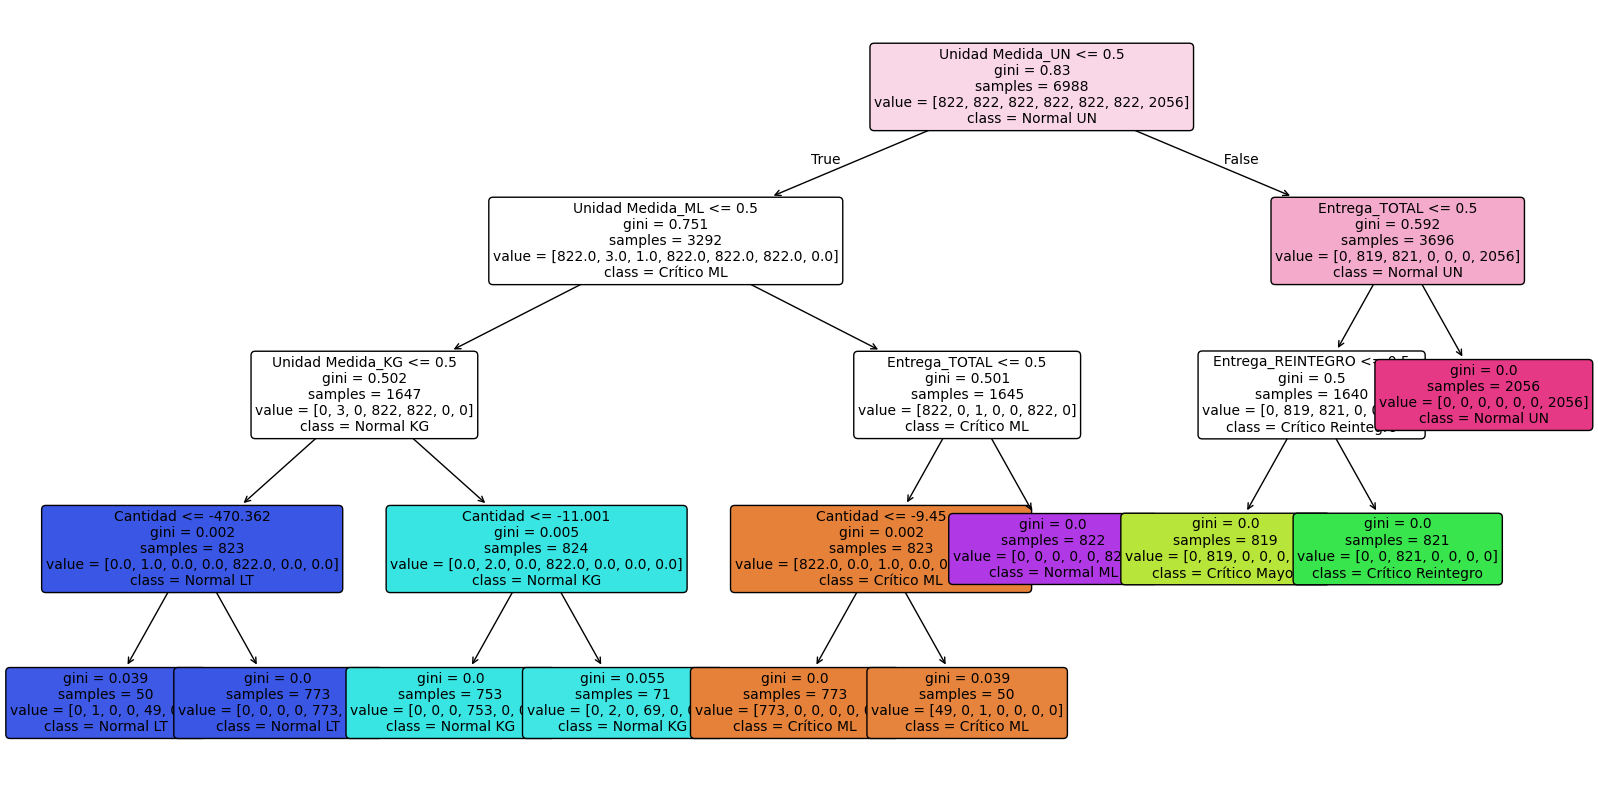

In [ ]:
# Graficar árbol
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Ajustar el modelo de árbol de decisión con los datos completos (X, Y)
# para poder graficar un árbol que represente el modelo.
# X e Y ya están preprocesados (dummies para categóricas, numéricas escaladas, objetivo label-encoded).
modelTree.fit(X, Y)

# Configurar el tamaño de la imagen
plt.figure(figsize=(20, 10))

# class_names: extraemos los nombres de las clases originales usando labelencoder
# feature_names: usamos los nombres de las columnas del DataFrame X
plot_tree(modelTree,
          feature_names=X.columns.values,
          class_names=labelencoder.classes_,
          rounded=True,
          filled=True,
          fontsize=10)

# Mostrar el gráfico
plt.show()

# RANDOM FOREST

In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

model_rf= RandomForestClassifier(n_estimators=200,  max_samples=0.7, criterion='gini',
                              max_depth=10, min_samples_leaf=20)

scores = cross_validate(model_rf, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
scores

,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro
0,0.671975,0.026276,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,0.654103,0.026481,1.000000,0.999421,1.000000,0.999523,1.000000,0.999423,1.000000,0.999421
2,0.648228,0.026213,0.996515,0.999614,0.997139,0.999682,0.996599,0.999615,0.996516,0.999614
3,0.638253,0.026488,0.998258,0.999614,0.998569,0.999682,0.998279,0.999615,0.998258,0.999614
4,0.658621,0.034326,0.998258,0.999807,0.998569,0.999841,0.998279,0.999807,0.998258,0.999807
5,0.638043,0.027932,1.000000,0.999228,1.000000,0.999364,1.000000,0.999232,1.000000,0.999228
6,0.656198,0.026305,1.000000,0.999807,1.000000,0.999841,1.000000,0.999807,1.000000,0.999807
7,0.801291,0.039400,1.000000,0.999807,1.000000,0.999841,1.000000,0.999807,1.000000,0.999807
8,0.983371,0.039893,1.000000,0.999421,1.000000,0.999523,1.000000,0.999423,1.000000,0.999421
9,0.975890,0.025606,1.000000,0.999807,1.000000,0.999841,1.000000,0.999807,1.000000,0.999807


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

,0
fit_time,0.732597
score_time,0.029892
test_f1_macro,0.999303
train_f1_macro,0.999653
test_accuracy,0.999428
train_accuracy,0.999714
test_precision_macro,0.999316
train_precision_macro,0.999654
test_recall_macro,0.999303
train_recall_macro,0.999652


In [ ]:
#Se almacena en el df la medida a comparar
comparacion_CV['RF']=scores['test_f1_macro']
comparacion_CV

,Tree,RF,Knn,NN,SVM
0,1.000000,1.000000,1.000000,1.000000,1.000000
1,1.000000,1.000000,1.000000,1.000000,1.000000
2,0.996505,0.996515,1.000000,0.998258,1.000000
3,0.998258,0.998258,1.000000,0.998258,0.998258
4,0.998258,0.998258,0.998258,1.000000,1.000000
5,1.000000,1.000000,1.000000,1.000000,1.000000
6,1.000000,1.000000,1.000000,1.000000,1.000000
7,1.000000,1.000000,1.000000,1.000000,1.000000
8,1.000000,1.000000,1.000000,1.000000,1.000000
9,1.000000,1.000000,1.000000,1.000000,1.000000


# KNN

In [ ]:
#Normalizacion las variables numéricas (las dummies no se normalizan)
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()

min_max_scaler.fit(X[predictoras_numericas]) #Ajuste de los parametros: max - min
X[predictoras_numericas]= min_max_scaler.transform(X[predictoras_numericas]) #70%
X.head()

,Numero de Transacciones,Cantidad,Reintegros,Precio Unitario,Unidad Medida_KG,Unidad Medida_LT,Unidad Medida_ML,Unidad Medida_UN,Entrega_PARCIAL,Entrega_REINTEGRO,Entrega_TOTAL
0,0.000000,0.999965,0.0,5.797535e-06,0,0,0,1,0,0,1
1,0.000000,0.999650,0.0,2.480966e-06,0,0,0,1,0,0,1
2,0.000000,0.996820,0.0,9.358983e-07,0,0,0,1,1,0,0
3,0.030769,0.999371,0.0,1.772631e-05,0,0,0,1,0,0,1
4,0.061538,0.998252,0.0,3.705203e-05,0,0,0,1,0,0,1


In [ ]:
#Método Perezoso
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier(n_neighbors=7, metric='euclidean')


scores = cross_validate(model_knn, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe

scores



,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro
0,0.012158,0.032268,1.000000,0.999807,1.000000,0.999841,1.000000,0.999807,1.000000,0.999807
1,0.016623,0.041325,1.000000,0.999807,1.000000,0.999841,1.000000,0.999807,1.000000,0.999807
2,0.017763,0.040652,1.000000,0.999807,1.000000,0.999841,1.000000,0.999807,1.000000,0.999807
3,0.021008,0.048111,1.000000,0.999807,1.000000,0.999841,1.000000,0.999807,1.000000,0.999807
4,0.017689,0.040916,0.998258,1.000000,0.998569,1.000000,0.998279,1.000000,0.998258,1.000000
5,0.018056,0.047888,1.000000,0.999807,1.000000,0.999841,1.000000,0.999807,1.000000,0.999807
6,0.018041,0.038366,1.000000,0.999807,1.000000,0.999841,1.000000,0.999807,1.000000,0.999807
7,0.018511,0.047472,1.000000,0.999807,1.000000,0.999841,1.000000,0.999807,1.000000,0.999807
8,0.019558,0.043011,1.000000,0.999807,1.000000,0.999841,1.000000,0.999807,1.000000,0.999807
9,0.010180,0.025244,1.000000,0.999807,1.000000,0.999841,1.000000,0.999807,1.000000,0.999807


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()



,0
fit_time,0.016959
score_time,0.040525
test_f1_macro,0.999826
train_f1_macro,0.999826
test_accuracy,0.999857
train_accuracy,0.999857
test_precision_macro,0.999828
train_precision_macro,0.999826
test_recall_macro,0.999826
train_recall_macro,0.999826


In [ ]:
#Se almacena en el df la medida a comparar
comparacion_CV['Knn']=scores['test_f1_macro']
comparacion_CV

,Tree,RF,Knn
0,1.000000,1.000000,1.000000
1,1.000000,1.000000,1.000000
2,0.996505,0.996515,1.000000
3,0.998258,1.000000,1.000000
4,0.998258,0.998258,0.998258
5,1.000000,1.000000,1.000000
6,1.000000,1.000000,1.000000
7,1.000000,1.000000,1.000000
8,1.000000,1.000000,1.000000
9,1.000000,1.000000,1.000000


# NN

In [ ]:
#Red neuronal

#Solo se configura capas ocultas, no se configura capa de entrada y de salida
#activation -> función activación de la oculta: tanh, logistic, linear, relu
#hidden_layer_sizes=5,7 -> dos capas ocultas con 5 neuronas y 7 neuronas
#learning_rate-> tamaño del paso constante o decreciente (constant, adaptive)
#learning_rate_init-> valor tasa de aprendizaje
#momentum-> valor momentum
#max_iter-> iteaciones
#random_state-> semilla para generacion numeros seudoaletorios
from sklearn.neural_network import MLPClassifier
model_rn = MLPClassifier(activation="logistic",hidden_layer_sizes=(3), learning_rate='constant',
                     learning_rate_init=0.02, momentum= 0.03, max_iter=100, random_state=3)

scores = cross_validate(model_rn, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe

scores

,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro
0,0.905437,0.009090,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
1,0.898511,0.008891,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
2,0.949313,0.009231,0.998258,1.0,0.998569,1.0,0.998279,1.0,0.998258,1.0
3,0.917701,0.008926,0.998258,1.0,0.998569,1.0,0.998279,1.0,0.998258,1.0
4,0.921632,0.009387,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
5,0.887121,0.008947,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
6,0.894744,0.008880,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
7,1.228967,0.014999,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
8,1.454329,0.014376,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
9,1.043184,0.009462,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

,0
fit_time,1.010094
score_time,0.010219
test_f1_macro,0.999652
train_f1_macro,1.000000
test_accuracy,0.999714
train_accuracy,1.000000
test_precision_macro,0.999656
train_precision_macro,1.000000
test_recall_macro,0.999652
train_recall_macro,1.000000


In [ ]:
#Se almacena en el df la medida a comparar
comparacion_CV['NN']=scores['test_f1_macro']
comparacion_CV

,Tree,RF,Knn,NN
0,1.000000,1.000000,1.000000,1.000000
1,1.000000,1.000000,1.000000,1.000000
2,0.996505,0.996515,1.000000,0.998258
3,0.998258,1.000000,1.000000,0.998258
4,0.998258,0.998258,0.998258,1.000000
5,1.000000,1.000000,1.000000,1.000000
6,1.000000,1.000000,1.000000,1.000000
7,1.000000,1.000000,1.000000,1.000000
8,1.000000,1.000000,1.000000,1.000000
9,1.000000,1.000000,1.000000,1.000000


# SVM

In [ ]:
#SVM
from sklearn.svm import SVC # SVR
model_svm=SVC(kernel='rbf', C=5)

scores = cross_validate(model_svm, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe

scores

,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro
0,0.030024,0.011217,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
1,0.030918,0.017405,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
2,0.026648,0.010625,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
3,0.027330,0.010490,0.998258,1.0,0.998569,1.0,0.998279,1.0,0.998258,1.0
4,0.027469,0.010683,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
5,0.028046,0.011015,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
6,0.029333,0.010381,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
7,0.029281,0.010605,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
8,0.025961,0.010790,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
9,0.027834,0.011407,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

,0
fit_time,0.028284
score_time,0.011462
test_f1_macro,0.999826
train_f1_macro,1.000000
test_accuracy,0.999857
train_accuracy,1.000000
test_precision_macro,0.999828
train_precision_macro,1.000000
test_recall_macro,0.999826
train_recall_macro,1.000000


In [ ]:
#Se almacena en el df la medida a comparar
comparacion_CV['SVM']=scores['test_f1_macro']
comparacion_CV

,Tree,RF,Knn,NN,SVM
0,1.000000,1.000000,1.000000,1.000000,1.000000
1,1.000000,1.000000,1.000000,1.000000,1.000000
2,0.996505,0.996515,1.000000,0.998258,0.996515
3,0.998258,0.998258,1.000000,0.998258,0.998258
4,0.998258,0.998258,0.998258,1.000000,0.998258
5,1.000000,1.000000,1.000000,1.000000,1.000000
6,1.000000,1.000000,1.000000,1.000000,1.000000
7,1.000000,1.000000,1.000000,1.000000,1.000000
8,1.000000,1.000000,1.000000,1.000000,1.000000
9,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
comparacion_CV

,Tree,RF,Knn,NN,SVM
0,1.000000,1.000000,1.000000,1.000000,1.000000
1,1.000000,1.000000,1.000000,1.000000,1.000000
2,0.996505,0.996515,1.000000,0.998258,0.996515
3,0.998258,0.998258,1.000000,0.998258,0.998258
4,0.998258,0.998258,0.998258,1.000000,0.998258
5,1.000000,1.000000,1.000000,1.000000,1.000000
6,1.000000,1.000000,1.000000,1.000000,1.000000
7,1.000000,1.000000,1.000000,1.000000,1.000000
8,1.000000,1.000000,1.000000,1.000000,1.000000
9,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: >

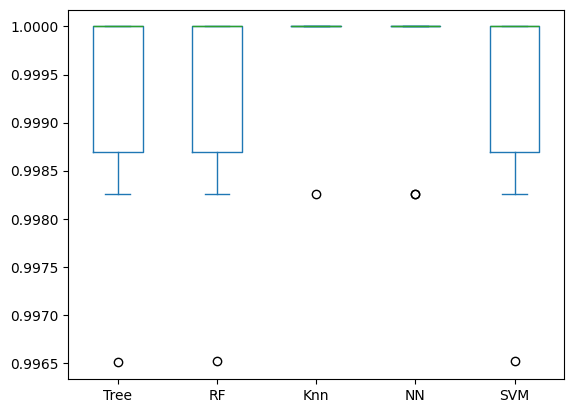

In [ ]:
#Resultados de la validación cruzada
comparacion_CV.plot(kind='box')

# 5. Guardamos el mejor modelo
Se entrena modelo final con 100% de los datos (X,Y)

In [ ]:
X[predictoras_numericas]= min_max_scaler.transform(X[predictoras_numericas])

In [ ]:
#Entrenamos modelo final
model_rn.fit(X, Y) #100%

MLPClassifier(activation='logistic', hidden_layer_sizes=50,
              learning_rate_init=0.02, max_iter=500, momentum=0.03,
              random_state=3)

In [ ]:
import pickle   # Para guardar el mejor modelo entrenado con el 100% de los datos. Con este archivo se puede cargar en otro notebook y se hace validación o predicción con otros datos
filename = 'modelo-class.pkl'
variables= X.columns._values
pickle.dump([model_rn, labelencoder,variables,min_max_scaler], open(filename, 'wb'))

